# 00 — Panorama general del corpus

Las cinco fuentes vistas a la vez: **qué hay, desde cuándo, cada cuánto y con qué
huecos**. Los cinco notebooks siguientes miran una tabla cada uno; este mira lo
que solo se ve comparándolas, que es justamente la pregunta que decide si el TFM
se puede hacer:

> ¿hay suficiente **solape temporal** entre las posiciones de los buses y el
> estado del tráfico como para fusionarlas?

Si las dos series no coinciden en el tiempo, no hay fusión posible y el resto del
análisis sobra. Es la condición de viabilidad, no un detalle de calidad.

**Contexto.** `data/curated/` es parquet particionado `source=/date=`,
reconstruible en cualquier momento desde `data/raw/` con
`python -m project.ingest.reprocesar`. Ninguna fuente publica histórico: lo que no
capturó el colector no existe y no se puede volver a pedir.

**Convención horaria.** Todo lo que sale aquí está en **UTC**. La conexión de
DuckDB fija `TimeZone='UTC'` a propósito (ver `eda_utils.con`): València está en
UTC+2 en verano y confundir las dos zonas es el error que ya costó la trampa 002.

In [1]:
import sys
from pathlib import Path

# El notebook debe correr tanto abierto desde notebooks/EDA como ejecutado
# desde la raíz del repo (nbclient, CI).
AQUI = Path("notebooks/EDA").resolve() if Path("notebooks/EDA").exists() else Path.cwd()
sys.path.insert(0, str(AQUI))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import eda_utils as eu

eu.estilo()
FUENTE = "(todas)"
print("corpus:", eu.dir_fuente(FUENTE))

corpus: C:\Users\oppen\Code\TFM\data\curated\source=(todas)


## 1. Censo

Filas, ficheros, particiones y rango temporal de cada fuente.

In [2]:
censos = pd.concat(
    [eu.censo(f).rename(columns={"valor": f}) for f in eu.FUENTES], axis=1
)
censos

,emt_buses,trafico_estado,trafico_intensidad,valenbisi,renfe_cercanias
métrica,,,,,
fuente,emt_buses,trafico_estado,trafico_intensidad,valenbisi,renfe_cercanias
filas,"5,163,031","2,754,220","713,048","1,148,238","456,312"
ficheros parquet,679,682,682,682,530
particiones (días),17,17,17,17,17
tamaño en disco,119.0 MB,19.6 MB,11.4 MB,25.7 MB,11.9 MB
ts_utc mínimo,2026-08-15 20:14:10+00:00,2026-08-15 20:14:39.247821+00:00,2026-08-15 20:14:39.249822+00:00,2026-07-20 07:33:55+00:00,2026-08-15 20:14:37+00:00
ts_utc máximo,2026-08-31 16:29:55+00:00,2026-08-31 16:40:50.932833+00:00,2026-08-31 16:18:02.901883+00:00,2026-08-31 16:32:37+00:00,2026-08-31 16:33:35+00:00


Dos cosas que ya chirrían en esta tabla:

- **`valenbisi` empieza un mes antes que las demás.** El colector arrancó el
  15/08 para las cinco, así que un `ts_utc` de julio no es captura antigua: es el
  reloj de la propia estación, que la fuente publica congelado. Se investiga en
  el notebook 04.
- **`emt_buses` tiene tantas filas como las otras cuatro juntas.** No es que
  haya más autobuses que tramos de tráfico: es que se sondea cada 30 s frente a
  los 5-15 min de las capas municipales. Esa asimetría de cadencia es la que
  obliga a decidir cómo se alinean las series al fusionar.

## 2. Cadencia real de sondeo

Lo que importa no es cada cuánto *pretende* sondear el colector, sino cada cuánto
lo consigue. Se mide sobre `ts_ingest_utc` —el reloj propio— y nunca sobre
`ts_utc`, que es el de la fuente y en la EMT alterna de convención.

El umbral de hueco es relativo (3 × la cadencia mediana) porque un umbral fijo de
10 minutos marcaría como avería el funcionamiento normal de la capa de
intensidad, que va a 15.

In [3]:
cad = pd.concat([eu.cadencia(f).assign(fuente=f) for f in eu.FUENTES])
cad = cad.set_index("fuente")[
    ["sondeos", "mediana_s", "media_s", "min_s", "p95_s", "max_s", "huecos", "horas_perdidas"]
]
cad.round(1)

,sondeos,mediana_s,media_s,min_s,p95_s,max_s,huecos,horas_perdidas
fuente,,,,,,,,
emt_buses,40942,30.000,33.400,30,31.000,53500,30.000,30.700
trafico_estado,6684,300.000,204.900,60,301.000,54675,11.000,29.600
trafico_intensidad,1818,900.000,752.600,232,901.000,54234,5.000,28.900
valenbisi,4205,300.000,325.600,232,301.000,54265,10.000,30.000
renfe_cercanias,30648,30.000,44.700,30,31.000,65920,97.000,121.900


`mediana_s` frente a `p95_s` mide la regularidad: si son casi iguales, el colector
va como un reloj y las desviaciones son paradas, no jitter. `max_s` es siempre la
parada más larga, y es la misma en las cinco fuentes — un colector caído las tira
a todas a la vez.

## 3. Cobertura temporal

Filas por día de cada fuente. Escala logarítmica porque `emt_buses` está dos
órdenes de magnitud por encima de `renfe_cercanias` y en lineal aplasta al resto.

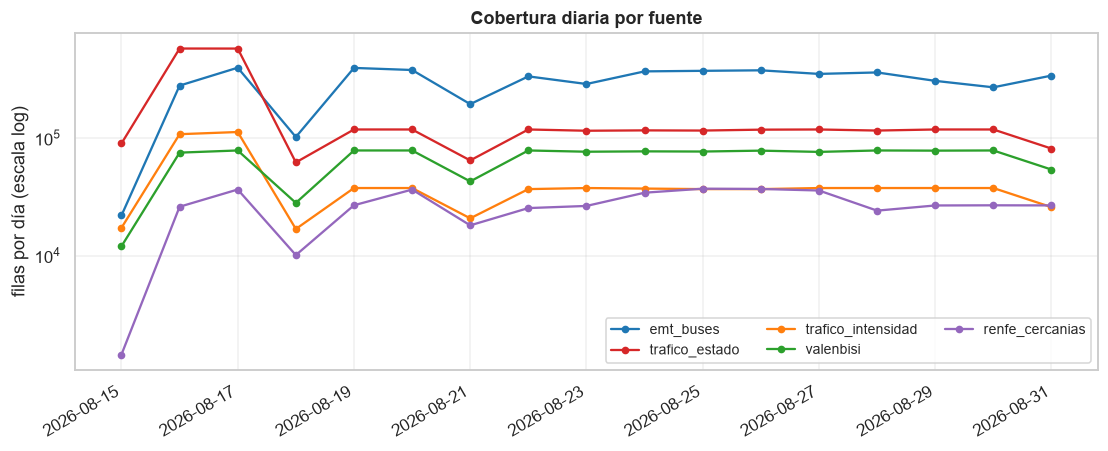

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
for f in eu.FUENTES:
    d = eu.filas_por_dia(f)
    ax.plot(d["dia"], d["filas"], marker="o", ms=4, label=f, color=eu.PALETA[f])
ax.set_yscale("log")
ax.set_ylabel("filas por día (escala log)")
ax.set_title("Cobertura diaria por fuente")
ax.legend(ncol=3, fontsize=9)
fig.autofmt_xdate()
plt.show()

Los días de los extremos están cortados (el colector arrancó a media tarde del
15/08 y el corpus se cierra a media tarde del 31/08). **No son días perdidos: son
días parciales**, y contarlos como completos falsearía cualquier media diaria.

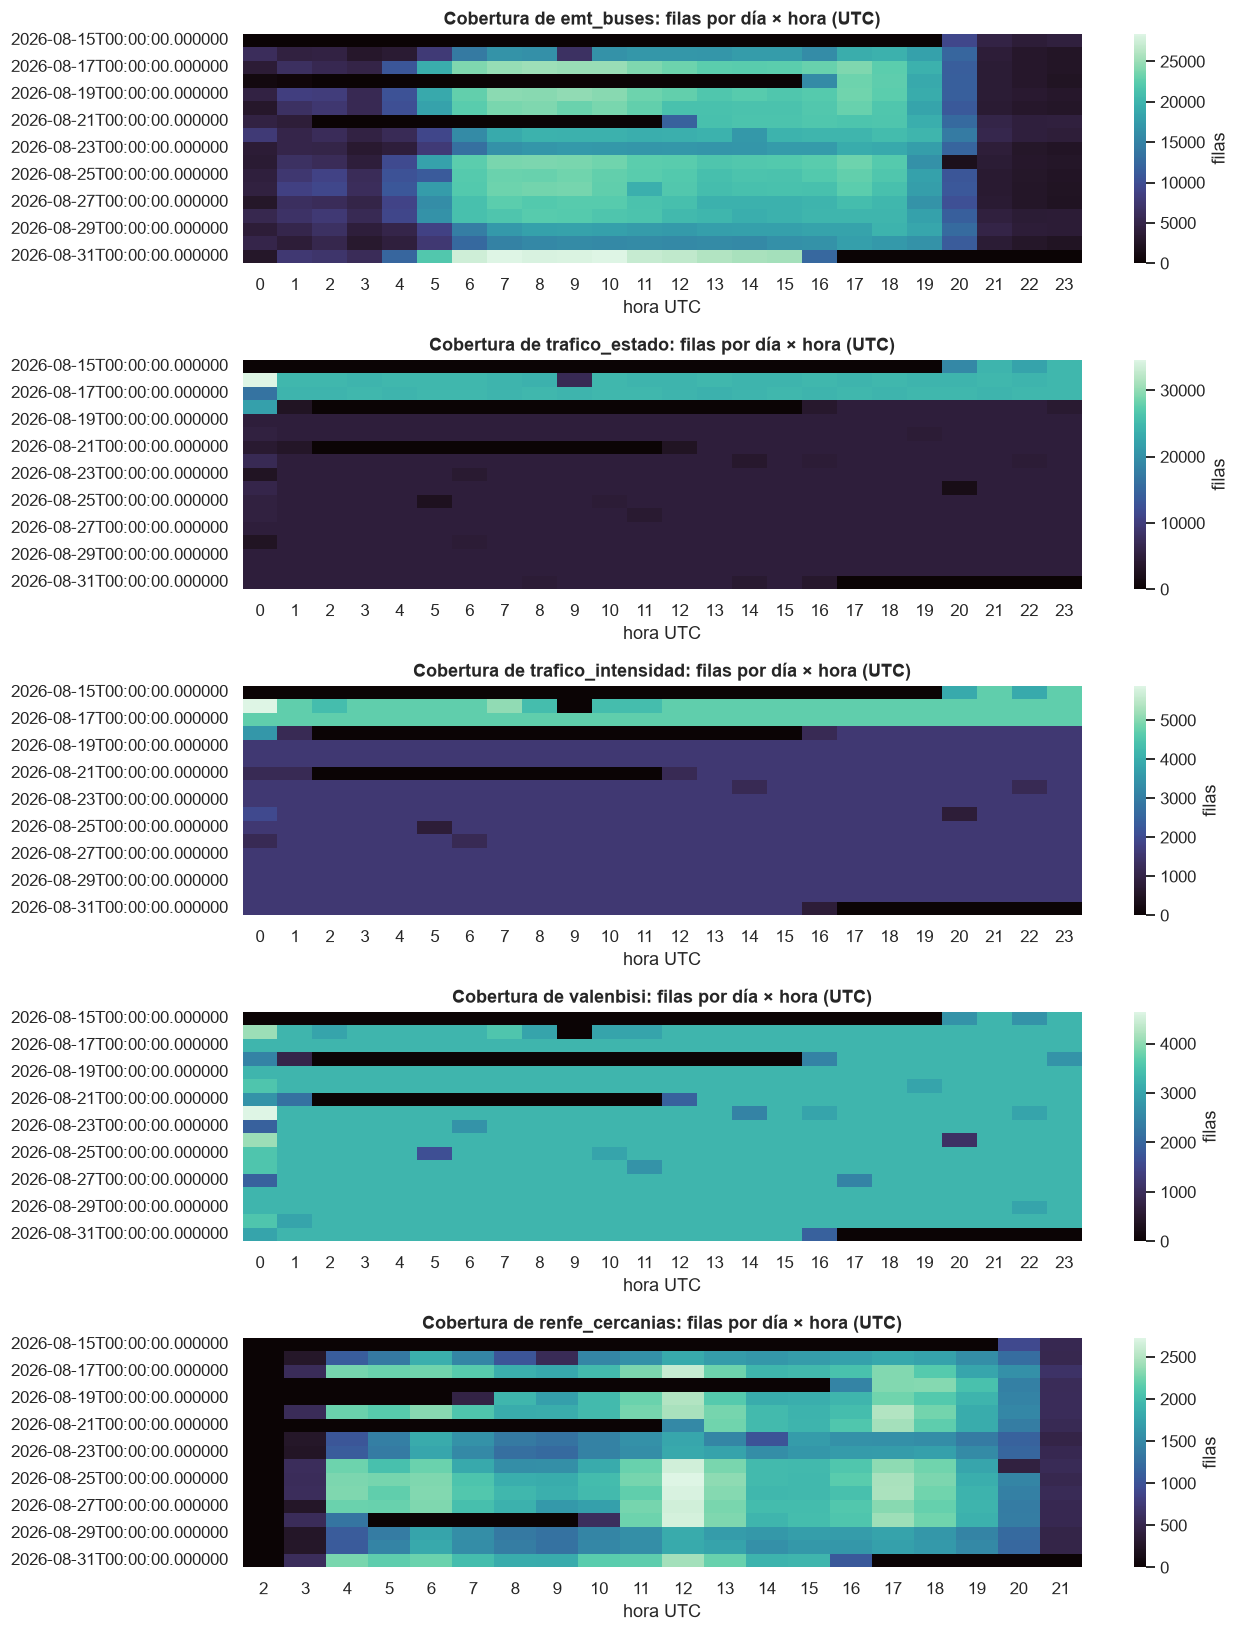

In [5]:
fig, axes = plt.subplots(len(eu.FUENTES), 1, figsize=(12, 3.0 * len(eu.FUENTES)))
for ax, f in zip(axes, eu.FUENTES):
    eu.heatmap_cobertura(f, ax=ax)
fig.tight_layout()
plt.show()

Las bandas blancas verticales que se repiten en las cinco filas son paradas del
colector, no ausencia de servicio. Las que aparecen en una sola fuente son fallos
de esa API concreta.

## 4. Huecos del colector

Todo salto de más de 3 × la cadencia mediana, ordenado por duración.

In [6]:
h = pd.concat([eu.huecos(f).assign(fuente=f) for f in eu.FUENTES])
h.sort_values("minutos", ascending=False).head(15).reset_index(drop=True)

,desde,hasta,minutos,fuente
0,2026-08-17 21:58:47.392673+00:00,2026-08-18 16:17:27.175772+00:00,"1,098.667",renfe_cercanias
1,2026-08-18 01:06:12.295884+00:00,2026-08-18 16:17:27.168849+00:00,911.250,trafico_estado
2,2026-08-18 01:13:02.603635+00:00,2026-08-18 16:17:27.178524+00:00,904.417,valenbisi
3,2026-08-18 01:13:33.442428+00:00,2026-08-18 16:17:27.171451+00:00,903.900,trafico_intensidad
4,2026-08-18 01:25:47.554366+00:00,2026-08-18 16:17:27.159732+00:00,891.667,emt_buses
5,2026-08-20 21:55:59.833674+00:00,2026-08-21 12:28:09.710107+00:00,872.167,renfe_cercanias
6,2026-08-21 01:32:36.733853+00:00,2026-08-21 12:28:09.662136+00:00,655.550,emt_buses
7,2026-08-21 01:33:21.594965+00:00,2026-08-21 12:28:09.707220+00:00,654.800,trafico_intensidad
8,2026-08-21 01:35:23.862573+00:00,2026-08-21 12:28:09.703876+00:00,652.767,trafico_estado
9,2026-08-21 01:35:24.054878+00:00,2026-08-21 12:28:09.713050+00:00,652.750,valenbisi


In [7]:
# ¿Cuántos de esos huecos son compartidos por las cinco fuentes? Un hueco
# compartido es una caída del colector o de la red; uno aislado, un fallo de esa
# API. La distinción importa: lo primero no se puede arreglar reprocesando.
grandes = h[h["minutos"] > 30].copy()
grandes["inicio_h"] = grandes["desde"].dt.floor("h")
compartidos = (
    grandes.groupby("inicio_h")
    .agg(fuentes=("fuente", "nunique"), minutos_max=("minutos", "max"))
    .sort_values("minutos_max", ascending=False)
)
compartidos

,fuentes,minutos_max
inicio_h,,
2026-08-17 21:00:00+00:00,1,"1,098.667"
2026-08-18 01:00:00+00:00,4,911.250
2026-08-20 21:00:00+00:00,1,872.167
2026-08-21 01:00:00+00:00,4,655.550
2026-08-18 21:00:00+00:00,1,591.217
2026-08-28 04:00:00+00:00,1,366.900
2026-08-26 21:00:00+00:00,1,358.717
2026-08-15 21:00:00+00:00,1,329.500
2026-08-21 21:00:00+00:00,1,329.200


La columna `fuentes` separa dos fenómenos que no se pueden tratar igual:

- **`fuentes = 4` → caída real del colector.** Ocurre a la vez en las cuatro capas
  municipales. Son ventanas que no existen en el corpus y no se pueden rellenar
  desde ninguna otra fuente.
- **`fuentes = 1` y siempre `renfe_cercanias`, empezando sobre las 21:00 UTC →
  no es un fallo.** Cercanías no circula de madrugada, `flota.json` se queda sin
  trenes y el colector no escribe filas porque no hay nada que escribir. Contar
  esas seis horas diarias como pérdida de datos sería inventarse una avería.

`emt_buses` no tiene ese hueco nocturno pese a que la EMT tampoco da servicio
completo de noche: la capa 384 sigue publicando los vehículos de las líneas
nocturnas. La ausencia de filas y la ausencia de servicio no son lo mismo, y hay
que distinguirlas fuente por fuente antes de imputar nada.

## 5. Latencia de ingesta

`ts_ingest_utc − ts_utc`: cuánto tiempo lleva el dato publicado cuando lo
capturamos. Es lo que acota **con cuánta antelación** puede anticiparse algo: una
fuente con dos minutos de latencia no sirve para predecir a treinta segundos.

In [8]:
piezas = []
for f in eu.FUENTES:
    piezas.append(
        eu.sql(
            """
            SELECT median(date_diff('second', ts_utc, ts_ingest_utc)) AS mediana_s,
                   quantile_cont(date_diff('second', ts_utc, ts_ingest_utc), 0.95) AS p95_s,
                   min(date_diff('second', ts_utc, ts_ingest_utc)) AS min_s,
                   max(date_diff('second', ts_utc, ts_ingest_utc)) AS max_s
            FROM {f}
            """,
            f=f,
        ).assign(fuente=f)
    )
lat = pd.concat(piezas).set_index("fuente")
lat.round(1)

,mediana_s,p95_s,min_s,max_s
fuente,,,,
emt_buses,25.000,44.000,-9,476
trafico_estado,0.000,0.000,0,0
trafico_intensidad,0.000,0.000,0,0
valenbisi,301.000,626.000,2,3661151
renfe_cercanias,10.000,19.000,-19,63


Tres lecturas de esta tabla, y ninguna es cosmética:

- **Las dos capas de tráfico dan latencia exactamente 0.** No es que lleguen
  instantáneamente: es que **no publican timestamp propio** y el colector escribe
  `ts_utc = ts_ingest_utc` (ver `parse_trafico_estado` en `ingest/sources.py`).
  Consecuencia: de esas capas no se puede saber cuánto tiempo llevaba medido el
  estado cuando lo leímos. El error de alineación de la sección 6 es por tanto un
  **suelo**, no el valor real.
- **`valenbisi` tiene un máximo absurdo** (más de mil horas). No es latencia de
  red: es el reloj congelado de un par de estaciones. Se diseca en el notebook 04.
- **`emt_buses` tiene una latencia mínima ligeramente negativa** (unos −9 s). Es
  deriva entre el reloj de la fuente y el nuestro, no un fallo de resolución
  horaria: un error de convención daría ±7200 s, no ±10. El chivato de la
  trampa 002 sigue siendo útil, pero el umbral es de horas, no de segundos.

## 6. Solape temporal buses × tráfico — la condición de viabilidad

La pregunta no es si las dos series existen a la vez, sino **qué antigüedad tiene
la última medida de tráfico disponible en el instante en que se observa un bus**.
Esa antigüedad es el error de alineación que arrastrará cualquier feature de
congestión: si es de minutos, la feature describe un tráfico que ya pasó.

Se mide con un `ASOF JOIN`: para cada sondeo de buses, el sondeo de tráfico más
reciente que no sea posterior.

In [9]:
solape = eu.sql(
    """
    WITH b AS (SELECT DISTINCT ts_ingest_utc AS tb FROM {b}),
         t AS (SELECT DISTINCT ts_ingest_utc AS tt FROM {t}),
         j AS (
            SELECT tb, date_diff('second', tt, tb) AS edad_s
            FROM b ASOF LEFT JOIN t ON b.tb >= t.tt
         )
    SELECT count(*) AS sondeos_bus,
           sum(CASE WHEN edad_s IS NULL THEN 1 ELSE 0 END) AS sin_trafico_previo,
           median(edad_s) AS edad_mediana_s,
           quantile_cont(edad_s, 0.95) AS edad_p95_s,
           max(edad_s) AS edad_max_s,
           100.0 * sum(CASE WHEN edad_s <= 300 THEN 1 ELSE 0 END) / count(*) AS pct_frescos_5min
    FROM j
    """,
    b="emt_buses",
    t="trafico_estado",
)
solape.round(1)

,sondeos_bus,sin_trafico_previo,edad_mediana_s,edad_p95_s,edad_max_s,pct_frescos_5min
0,40943,1.000,124.000,284.000,54675,99.600


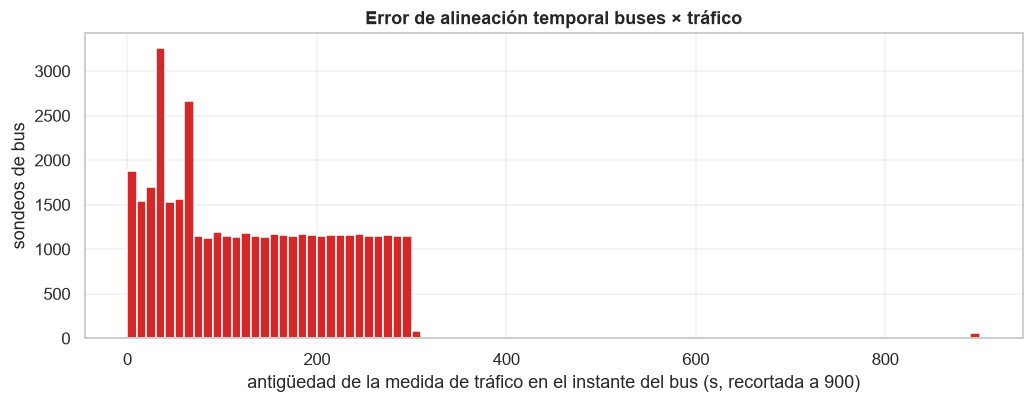

In [10]:
edades = eu.sql(
    """
    WITH b AS (SELECT DISTINCT ts_ingest_utc AS tb FROM {b}),
         t AS (SELECT DISTINCT ts_ingest_utc AS tt FROM {t})
    SELECT date_diff('second', tt, tb) AS edad_s
    FROM b ASOF LEFT JOIN t ON b.tb >= t.tt
    """,
    b="emt_buses",
    t="trafico_estado",
).dropna()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.hist(edades["edad_s"].clip(upper=900), bins=90, color=eu.PALETA["trafico_estado"])
ax.set_xlabel("antigüedad de la medida de tráfico en el instante del bus (s, recortada a 900)")
ax.set_ylabel("sondeos de bus")
ax.set_title("Error de alineación temporal buses × tráfico")
plt.show()

**La fusión es viable.** Prácticamente todos los sondeos de buses tienen una
medida de tráfico anterior a menos de cinco minutos, con una mediana de unos dos:
la antigüedad se reparte casi uniformemente entre 0 y 300 s, que es exactamente lo
que cabe esperar de una capa refrescada cada 5 min leída por otra que va a 30 s.

Dos matices que hay que escribir en la memoria antes de presumir de tiempo real:

- **ese ~2 min es el desfase de captura, no el de la medida.** Como la capa 192 no
  publica timestamp propio (sección 5), no sabemos cuánto llevaba calculado el
  estado cuando lo leímos. El error real de alineación es este **más** una
  cantidad desconocida;
- **la cola llega hasta las horas**, no hasta los 5 minutos: durante las paradas
  del colector el último tráfico conocido envejece tanto como dure el hueco.
  `prepare.py` necesita una política explícita de caducidad —a partir de qué
  antigüedad la medida de tráfico deja de valer— en vez de arrastrar el último
  valor conocido indefinidamente.

## 7. Deriva de esquema dentro del propio corpus

Los ficheros de una misma fuente **no tienen todos las mismas columnas**. Conviene
verlo aquí porque rompe cualquier lectura ingenua del glob de parquet.

In [11]:
import collections

import pyarrow.parquet as pq

filas = []
for f in eu.FUENTES:
    cnt = collections.Counter()
    for p in eu.dir_fuente(f).glob("**/*.parquet"):
        cnt[tuple(pq.read_schema(p).names)] += 1
    for cols, n in cnt.most_common():
        filas.append({"fuente": f, "ficheros": n, "columnas": len(cols), "esquema": ", ".join(cols)})
deriva = pd.DataFrame(filas)
deriva[["fuente", "ficheros", "columnas"]]

,fuente,ficheros,columnas
0,emt_buses,679,10
1,trafico_estado,598,6
2,trafico_estado,84,9
3,trafico_intensidad,598,7
4,trafico_intensidad,84,9
5,valenbisi,682,11
6,renfe_cercanias,530,15


In [12]:
for f in eu.FUENTES:
    sub = deriva[deriva["fuente"] == f]
    if len(sub) > 1:
        print("==", f)
        conjuntos = [set(s.split(", ")) for s in sub["esquema"]]
        print("   columnas que faltan en algún fichero:", sorted(set.union(*conjuntos) - set.intersection(*conjuntos)))

== trafico_estado
   columnas que faltan en algún fichero: ['lat', 'lon', 'n_vertices']
== trafico_intensidad
   columnas que faltan en algún fichero: ['lat', 'lon']


Las dos capas de tráfico tienen dos esquemas: los ficheros reprocesados traen
`lat`, `lon` (y `n_vertices` en la 192) y los capturados en vivo no. **No es un
bug del colector, es su diseño**: la geometría de un tramo no cambia, así que se
descarga una vez a `data/reference/*_geometria.parquet` y a partir de ahí la capa
se pide sin ella — es el 90 % del payload de la 192.

Consecuencia práctica, y no menor:

- leer el glob sin `union_by_name=1` **aborta** con *schema mismatch*;
- `lat`/`lon` de las capas de tráfico en `curated/` salen mayoritariamente nulos,
  y quien quiera situar un tramo tiene que unir contra `data/reference/`
  (`eu.geometria("trafico_estado")`).

## 8. Hallazgos

1. **La fusión es viable.** Casi todos los sondeos de buses tienen tráfico
   anterior a menos de 5 minutos, con mediana en torno a 2. Es la condición que
   había que verificar antes de seguir, y se cumple.
2. **Pero el desfase medido es un suelo, no el error real.** Las capas de tráfico
   no publican timestamp propio: el colector escribe `ts_utc = ts_ingest_utc`, así
   que la antigüedad de la *medida* (frente a la de la *captura*) es desconocida.
   Hay que declararlo como límite del estudio, no dejarlo implícito.
3. **El desequilibrio de cadencia (30 s vs 5 min vs 15 min) es estructural.**
   `prepare.py` necesita una política explícita de alineación **y de caducidad**:
   durante los huecos, el último tráfico conocido envejece horas, y arrastrarlo
   sin límite mete datos falsos con aspecto de válidos.
4. **Hay que distinguir caída del colector de ausencia de servicio.** Los huecos
   con cuatro fuentes a la vez son caídas reales; los nocturnos de
   `renfe_cercanias` son que no circulan trenes. Tratarlos igual falsearía tanto
   la disponibilidad como cualquier imputación.
5. **El esquema no es homogéneo dentro de una fuente.** Toda lectura del corpus
   necesita `union_by_name=1`, y la geometría de tráfico vive en
   `data/reference/`, no en `curated/`.
6. **`valenbisi` trae timestamps de fuera del periodo de captura.** Se investiga
   en el notebook 04; hasta entonces, no usar su `ts_utc` como reloj.
7. **Los días extremos son parciales.** Cualquier media diaria debe excluirlos o
   normalizar por horas cubiertas.